# Data

> Data classes and functions

In [ ]:
#| default_exp data

In [ ]:
#| hide
from nbdev.showdoc import *

## Data types

In [ ]:
#| export
import os
import numpy as np
import h5py
from tqdm import tqdm 
import random

from bioMONAI.core import MetaTensor, torchTensor, BypassNewMeta, DisplayedTransform, torchsqueeze, Path, List, L, torchmax, randint, typedispatch
from bioMONAI.io import image_reader
from bioMONAI.visualize import show_images_grid

from fastai.vision.all import DataBlock, TfmdDL, get_image_files, TransformBlock, get_grid, merge, show_image, RandomSplitter

### Meta resolver

In [ ]:
#| export

class MetaResolver(type(torchTensor), metaclass=BypassNewMeta):
    """
    A class to bypass metaclass conflict:
    https://pytorch-geometric.readthedocs.io/en/latest/_modules/torch_geometric/data/batch.html
    """
    pass
    

### BioImageBase

In [ ]:
#| export
class BioImageBase(MetaTensor, metaclass=MetaResolver):
    """
    A class that represents an image object.
    Metaclass casts `x` to this class if it is of type `cls._bypass_type`.
    """
    
    _bypass_type = torchTensor  # The type that bypasses image loading
    _show_args = {'cmap': 'gray'}  # Default arguments for image display
    resample, reorder = None, False  # Default resample and reorder settings
    affine_matrix = None  # Default affine matrix for image transformation

    @classmethod
    def create(cls, fn: (Path, str, List, torchTensor), **kwargs) -> torchTensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torchTensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torchTensor)
                Image path or a 4D torchTensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torchTensor : A 4D tensor as a BioImageBase object.
        """
        if isinstance(fn, torchTensor):
            return cls(fn)

        return image_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)

    @classmethod
    def item_preprocessing(cls, resample: (List, int, tuple), reorder: bool):
        """
        Changes the values for the class variables `resample` and `reorder`.

        Args:
            resample : (List, int, tuple)
                A list with voxel spacing.
            reorder : bool
                Whether to reorder the data to be closest to canonical (RAS+) orientation.
        """
        cls.resample = resample
        cls.reorder = reorder

    def show(self, ctx=None, figsize: int = None, ncols: int = 10, **kwargs):
        """
        Plots 2D slices of a 3D image alongside a prior specified axis.

        Args:
            ctx : Context to use for the display. Defaults to None.
            figsize: Size of the figure. Defaults to None.
            ncols: Number of columns in the grid. Defaults to 10.
            **kwargs : Additional keyword arguments passed to plt.imshow.

        Returns:
            Shown image.
        """
        return show_images_grid(self, ctx=ctx, ncols=ncols, **merge(self._show_args, kwargs))
    
    def as_tensor(self) -> torchTensor:
        """
        Return the `MetaTensor` as a `torchTensor`.
        It is OS dependent as to whether this will be a deep copy or not.
        """
        return self.as_subclass(torchTensor)

    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageBase{self.as_tensor().__repr__()[6:]}"

### BioImage 

class for 2D Images

In [ ]:
#| export

class BioImage(BioImageBase):
    """Subclass of BioImageBase that represents 2D and 3D image objects."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torchTensor), **kwargs) -> torchTensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torchTensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torchTensor)
                Image path or a 4D torchTensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torchTensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torchTensor):
            return cls(fn)

        return torchsqueeze(image_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
    #     return f'{self.__class__.__name__} shape={"x".join([str(d) for d in self.shape])}'
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [ ]:
a = BioImage.create('data_examples/example_tiff.tiff')
print(a.shape)





torch.Size([1, 96, 512, 512])


### BioImageStack

class for 3D images

In [ ]:
#| export

class BioImageStack(BioImageBase):
    """Subclass of BioImageBase that represents a 3D image object."""
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageStack{self.as_tensor().__repr__()[6:]}"

In [ ]:
a = BioImageStack.create('data_examples/example_tiff.tiff')
print(a.shape)

torch.Size([1, 96, 512, 512])


### BioImageProject

2D representations of 3D stack using maximum intensity projection

In [ ]:
#| export

class BioImageProject(BioImageBase):
    """Subclass of BioImageBase that represents a 2D image object."""
    _show_args = {'cmap':'gray'}
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torchTensor), **kwargs) -> torchTensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torchTensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torchTensor)
                Image path or a 4D torchTensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torchTensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torchTensor):
            return cls(fn)

        img = image_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder)
        return torchmax(img, dim=1)[0]  # Taking the maximum intensity projection along axis 1
    
    def show(self, ctx=None, **kwargs):
        "Show image using `merge(self._show_args, kwargs)`"
        return show_image(self, ctx=ctx, **merge(self._show_args, kwargs))
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage{self.as_tensor().__repr__()[6:]}"

In [ ]:
a = BioImageProject.create('data_examples/example_tiff.tiff')
#a = BioImageProject.create('../../bioMONAI_0/_data/Thunder_20230308/nuevos_datos/dataset_2/inputs/1.tif')
a.shape

torch.Size([1, 512, 512])

### BioImageMulti

Multichannel datasets

In [ ]:
#| export

class BioImageMulti(BioImageBase):
    """Subclass of BioImageBase that represents a multi-channel 2D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torchTensor), **kwargs) -> torchTensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torchTensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torchTensor)
                Image path or a 4D torchTensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torchTensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torchTensor):
            return cls(fn)

        return torchsqueeze(image_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 0)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImageMulti{self.as_tensor().__repr__()[6:]}"
        

In [ ]:
# a = BioImageMulti.create('../../bioMONAI_0/_data/Babesia/RI/O11_RI_frame01.tiff')#'../_data/Babesia/RI/O11_RI_frame01.tiff'
# print(a.shape)

### BioImage4D

4D datasets

In [ ]:
# TO FINISH

class BioImage4D(BioImageBase):
    """Subclass of BioImageBase that represents a (multi-channel) 3D image object."""
    
    @classmethod
    def create(cls, fn: (Path, str, L, list, torchTensor), **kwargs) -> torchTensor: 
        """
        Opens an image and casts it to BioImageBase object.
        If `fn` is a torchTensor, it's cast to BioImageBase object.

        Args:
            fn : (Path, str, torchTensor)
                Image path or a 4D torchTensor.
            kwargs : dict
                Additional parameters for the medical image reader.

        Returns:
            torchTensor : A 3D tensor as a BioImage object.
        """
        if isinstance(fn, torchTensor):
            return cls(fn)

        return torchsqueeze(image_reader(fn, dtype=cls, resample=cls.resample, reorder=cls.reorder), 1)
    
    def __repr__(self) -> str:
        """Returns the string representation of the ImageBase instance."""
        return f"BioImage4D{self.as_tensor().__repr__()[6:]}"

In [ ]:
# from torch import randn as torchrandn

# b = BioImage4D.create(torchrandn(3,10, 4, 5))#'../_data/Babesia/RI/O11_RI_frame01.tiff'
# print(b.shape)

### Data conversion

In [ ]:
#| export

class Tensor2BioImage(DisplayedTransform):
    def __init__(self, cls:BioImageBase=BioImageStack):
        self.cls = cls

    def encodes(self, o):
        if isinstance(o, MetaTensor):
            return self.cls(o.clone(), affine=o.affine, meta=o.meta)
        
        if isinstance(o, torchTensor):
            return self.cls(o)

## Data blocks and Dataloader

In [ ]:
#| export
def BioImageBlock(cls:BioImageBase=BioImage):
    "A `TransformBlock` for images of `cls`"
    return TransformBlock(type_tfms=cls.create, batch_tfms=[Tensor2BioImage(cls)]) # IntToFloatTensor

In [ ]:
#| export
class BioDataBlock(DataBlock):
    def __init__(self, 
            blocks:list=(BioImageBlock(cls=BioImage), BioImageBlock(cls=BioImage)), # One or more `TransformBlock`s
            dl_type:TfmdDL=None, # Task specific `TfmdDL`, defaults to `block`'s dl_type or`TfmdDL`
            get_items=get_image_files,
            get_y=None,
            get_x=None,
            getters:list=None, # Getter functions applied to results of `get_items`
            n_inp:int=None, # Number of inputs
            item_tfms:list=None, # `ItemTransform`s, applied on an item 
            batch_tfms:list=None, # `Transform`s or `RandTransform`s, applied by batch
            **kwargs, 
        ):
        super().__init__(
            blocks=blocks, 
            dl_type=dl_type, 
            get_items=get_items,
            get_y=get_y,
            get_x=get_x,
            getters=getters, 
            n_inp=n_inp, 
            item_tfms=item_tfms, 
            batch_tfms=batch_tfms,
            **kwargs,
            )
        

In [ ]:
#| export
def get_dataloader(data_source, show_summary:bool=False, **kwargs):
    """
    Create and return a DataLoader from a BioDataBlock using provided keyword arguments.
    
    Args:
        data_source (any): The source of the data to be loaded by the dataloader.
                            This can be any type that is compatible with the dataloading method 
                            specified in kwargs (e.g., paths, datasets).
        show_summary (bool, optional): If True, print a summary of the BioDataBlock after creation.
                                       Default is False.
        **kwargs: Additional keyword arguments to configure the DataLoader and BioDataBlock.
                  Supported keys include: 'blocks', 'dl_type', 'get_items', 'get_y', 
                  'get_x', 'getters', 'n_inp', 'item_tfms', 'batch_tfms'.
    
    Returns:
        DataLoader: A PyTorch DataLoader object populated with the data from the BioDataBlock.
                     If show_summary is True, it also prints a summary of the datablock after creation.
    
    Example:
        >>> dataloader = get_dataloader(data_path, show_summary=True, blocks='train', dl_type='ImageDataLoader')
    """
    # Define the keys for BioDataBlock operations
    datablock_ops_keys = ['blocks','dl_type','get_items','get_y','get_x','getters','n_inp','item_tfms','batch_tfms']
    
    # Filter and assign kwargs to datablock_ops dictionary for BioDataBlock initialization
    datablock_ops = {key: value for key, value in kwargs.items() if key in datablock_ops_keys}
    
    # Filter and assign remaining kwargs to dataloader_ops dictionary for DataLoader creation
    dataloader_ops = {key: value for key, value in kwargs.items() if key not in datablock_ops_keys}
    
    # Initialize BioDataBlock with specified operations
    datablock = BioDataBlock(**datablock_ops)
    
    # Create and return the DataLoader from the initialized BioDataBlock
    dataloder = datablock.dataloaders(data_source, **dataloader_ops)
    
    # Optionally print a summary of the BioDataBlock if show_summary is True
    if show_summary:
        print(datablock.summary(data_source))
    
    return dataloder


## Data getters

Get the ground truth images located in a folder called 'gt' and divided in labeled subfolders.

> These function are tailor-made for some test datasets, eventually they must be changed/adapted to more general cases


In [ ]:
#| export
from fastai.vision.all import get_image_files

In [ ]:
#| export
def get_gt(path, gt_file_name="avg50.png"): 
    def _fn(fn): return Path(path/"gt")/f"{parent_label(fn)}"/gt_file_name
    return _fn


In [ ]:
#| export
def get_target(path, same_filename=True, target_file_prefix="target", signal_file_prefix="signal"):
    # Define a function to construct the target file name based on input parameters
    def construct_target_filename(file_name):
        # Split the file name based on the signal file prefix
        parts = file_name.split(signal_file_prefix)
        
        # Construct the target file name by inserting the target file prefix
        target_file_name = parts[0] + target_file_prefix + parts[1]
        
        return target_file_name
    
    # Define a function to generate the target file path based on the given file name
    def generate_target_path(file_name):
        # Extract the base file name
        base_filename = os.path.basename(file_name)
        
        # If same_filename is True, simply return the path joined with the base file name
        if same_filename:
            return Path(path) / base_filename
        
        # If same_filename is False, construct the target file name and return the path joined with it
        target_filename = construct_target_filename(base_filename)
        return Path(path) / target_filename
    
    # Return the appropriate function based on the value of same_filename
    return generate_target_path


In [ ]:
print(get_target('train_folder/target', same_filename=False)('../signal/signal01.tif'))
print(get_target('train_folder/target')('../signal/image01.tif'))

train_folder/target/target01.tif
train_folder/target/image01.tif


In [ ]:
print(get_target('train_folder', same_filename=False, target_file_prefix="cameraman_clean", signal_file_prefix="cameraman_noisy")('../signal/cameraman_noisy.tif'))

train_folder/cameraman_clean.tif


Get as ground truth another noisy image randomly chosen in the same folder as the input image


In [ ]:
#| export
def get_noisy_pair(fn):
    tmp = get_image_files(fn.parent, recurse=False)
    fn2 = tmp[randint(0,len(tmp)-1)]
    while fn2 == fn: fn2 = tmp[randint(0,len(tmp)-1)]
    return fn2

## Data Display

### Show batch

In [ ]:
#| export 

@typedispatch
def show_batch(x:BioImageBase, y:BioImageBase, samples, ctxs=None, max_n=10, nrows=None, ncols=None, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(min(len(samples), max_n), nrows=nrows, ncols=ncols, figsize=figsize, double=True)
    for i in range(2):
        ctxs[i::2] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::2],range(max_n))]
    return ctxs

### Show results

In [ ]:
#| export 

@typedispatch
def show_results(x:BioImageBase, y:BioImageBase, samples, outs, ctxs=None, max_n=10, figsize=None, **kwargs):
    if ctxs is None: ctxs = get_grid(3*min(len(samples), max_n), ncols=3, figsize=figsize, title='Input/Target/Prediction')
    for i in range(2):
        ctxs[i::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(samples.itemgot(i),ctxs[i::3],range(max_n))]
    ctxs[2::3] = [b.show(ctx=c, **kwargs) for b,c,_ in zip(outs.itemgot(0),ctxs[2::3],range(max_n))]
    return ctxs

## Preprocessing

In [ ]:
#| export
def extract_patches(data, patch_size, overlap):
    """
    Extracts n-dimensional patches from the input data.
    
    Parameters:
    - data: numpy array of the input data (n-dimensional).
    - patch_size: tuple of integers defining the size of the patches in each dimension.
    - overlap: float (between 0 and 1) indicating overlap between patches.
    
    Returns:
    - A list of patches as numpy arrays.
    """
    data_shape = data.shape
    strides = tuple(int(p * (1 - overlap)) for p in patch_size)  # Calculate the stride for each dimension
    
    # Compute the range of indices for each dimension
    slices = [range(0, data_shape[i] - patch_size[i] + 1, strides[i]) for i in range(len(patch_size))]
    
    # Generate patches
    patches = []
    for indices in np.ndindex(*[len(s) for s in slices]):
        # Create slices for each dimension
        patch_slices = tuple(slice(slices[dim][idx], slices[dim][idx] + patch_size[dim]) for dim, idx in enumerate(indices))
        patches.append(data[patch_slices])
    
    return patches

In [ ]:
#| export
def save_patches_grid(data_folder, gt_folder, output_folder, patch_size, overlap):
    """
    Loads n-dimensional data from data_folder and gt_folder, generates patches, and saves them into individual HDF5 files.
    Each HDF5 file will have datasets with the structure X/patch_idx and y/patch_idx.
    
    Parameters:
    - data_folder: Path to the folder containing data files (n-dimensional data).
    - gt_folder: Path to the folder containing ground truth (gt) files (n-dimensional data).
    - output_folder: Path to the folder where the HDF5 files will be saved.
    - patch_size: tuple of integers defining the size of the patches.
    - overlap: float (between 0 and 1) defining the overlap between patches.
    """
    
    # Ensure output folder exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Ensure the folders contain the same number of files
    data_files = sorted([f for f in os.listdir(data_folder) if f.endswith(('.npy', '.npz', '.png', '.tif', '.tiff'))])
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.npy', '.npz', '.png', '.tif', '.tiff'))])
    
    print(data_files)
    
    if len(data_files) != len(gt_files):
        raise ValueError("The number of files in data_folder and gt_folder must be the same.")
    
    # Loop through the files in the folders with progress bar
    for data_file_name, gt_file_name in tqdm(zip(data_files, gt_files), total=len(data_files), desc="Processing files"):
        data_file_path = os.path.join(data_folder, data_file_name)
        gt_file_path = os.path.join(gt_folder, gt_file_name)
        
        # Load the images 
        data = np.array(image_reader(data_file_path)[0])
        gt = np.array(image_reader(gt_file_path)[0])
        
        if data.shape != gt.shape:
            raise ValueError(f"Shape mismatch between {data_file_name} and {gt_file_name}")
        
        # Extract patches from both datasets
        data_patches_nd = extract_patches(data, patch_size, overlap)
        gt_patches_nd = extract_patches(gt, patch_size, overlap)
        
        # Create a new HDF5 file for this pair of files
        hdf5_filename = os.path.join(output_folder, f"{os.path.splitext(data_file_name)[0]}.h5")
        
        with h5py.File(hdf5_filename, 'w') as hf:
            # Store each patch in a separate dataset with a progress bar for each file
            for patch_idx, (data_patch, gt_patch) in enumerate(tqdm(zip(data_patches_nd, gt_patches_nd), 
                                                                    total=len(data_patches_nd), 
                                                                    desc=f"Saving patches for {data_file_name}", 
                                                                    leave=False)):
                hf.create_dataset(f'X/{patch_idx}', data=data_patch)
                hf.create_dataset(f'y/{patch_idx}', data=gt_patch)
        

In [ ]:
data_folder = '/home/biagio/Code/Noise2Model/_data/Confocal_BPAE_B/raw/1'
gt_folder = '/home/biagio/Code/Noise2Model/_data/Confocal_BPAE_B/raw/1'
output_folder = './_test'
patch_size = (64,64)
overlap =0
save_patches_grid(data_folder, gt_folder, output_folder, patch_size, overlap)

['HV110_P0500510000.png', 'HV110_P0500510001.png', 'HV110_P0500510002.png', 'HV110_P0500510003.png', 'HV110_P0500510004.png', 'HV110_P0500510005.png', 'HV110_P0500510006.png', 'HV110_P0500510007.png', 'HV110_P0500510008.png', 'HV110_P0500510009.png', 'HV110_P0500510010.png', 'HV110_P0500510011.png', 'HV110_P0500510012.png', 'HV110_P0500510013.png', 'HV110_P0500510014.png', 'HV110_P0500510015.png', 'HV110_P0500510016.png', 'HV110_P0500510017.png', 'HV110_P0500510018.png', 'HV110_P0500510019.png', 'HV110_P0500510020.png', 'HV110_P0500510021.png', 'HV110_P0500510022.png', 'HV110_P0500510023.png', 'HV110_P0500510024.png', 'HV110_P0500510025.png', 'HV110_P0500510026.png', 'HV110_P0500510027.png', 'HV110_P0500510028.png', 'HV110_P0500510029.png', 'HV110_P0500510030.png', 'HV110_P0500510031.png', 'HV110_P0500510032.png', 'HV110_P0500510033.png', 'HV110_P0500510034.png', 'HV110_P0500510035.png', 'HV110_P0500510036.png', 'HV110_P0500510037.png', 'HV110_P0500510038.png', 'HV110_P0500510039.png',

Processing files: 100%|██████████| 50/50 [00:01<00:00, 36.53it/s]


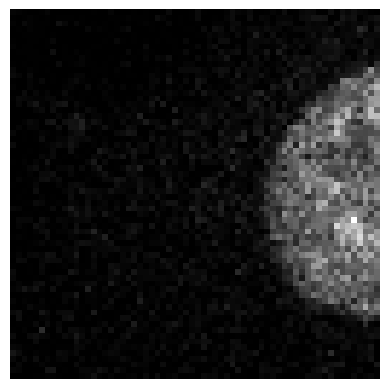

In [ ]:
from bioMONAI.io import hdf5_reader
from bioMONAI.visualize import plot_image

file_path = './_test/HV110_P0500510000.h5/X/1'

im , _ = hdf5_reader()(file_path)
plot_image(im)


In [ ]:
#| export
def extract_random_patches(data, patch_size, num_patches):
    """
    Extracts a specified number of random n-dimensional patches from the input data.
    
    Parameters:
    - data: numpy array of the input data (n-dimensional).
    - patch_size: tuple of integers defining the size of the patches in each dimension.
    - num_patches: number of random patches to extract.
    
    Returns:
    - A list of randomly cropped patches as numpy arrays.
    """
    data_shape = data.shape
    ndim = len(data_shape)
    
    # Ensure patch size fits within the data dimensions
    for dim in range(ndim):
        if patch_size[dim] > data_shape[dim]:
            raise ValueError(f"Patch size {patch_size[dim]} exceeds data dimension {data_shape[dim]} in dimension {dim}")
    
    patches = []
    
    for _ in range(num_patches):
        # Randomly select the starting point for each dimension
        start_coords = [random.randint(0, data_shape[dim] - patch_size[dim]) for dim in range(ndim)]
        
        # Create slices for the selected patch
        patch_slices = tuple(slice(start_coords[dim], start_coords[dim] + patch_size[dim]) for dim in range(ndim))
        
        # Extract the patch and add to the list
        patches.append(data[patch_slices])
    
    return patches


In [ ]:
#| export
def save_patches_random(data_folder, gt_folder, output_folder, patch_size, num_patches):
    """
    Loads n-dimensional data from data_folder and gt_folder, generates random patches, and saves them into individual HDF5 files.
    Each HDF5 file will have datasets with the structure X/patch_idx and y/patch_idx.
    
    Parameters:
    - data_folder: Path to the folder containing data files (n-dimensional data).
    - gt_folder: Path to the folder containing ground truth (gt) files (n-dimensional data).
    - output_folder: Path to the folder where the HDF5 files will be saved.
    - patch_size: tuple of integers defining the size of the patches.
    - num_patches: number of random patches to extract per file.
    """
    
    # Ensure output folder exists
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Ensure the folders contain the same number of files
    data_files = sorted([f for f in os.listdir(data_folder) if f.endswith(('.npy', '.npz', '.png', '.tif', '.tiff'))])
    gt_files = sorted([f for f in os.listdir(gt_folder) if f.endswith(('.npy', '.npz', '.png', '.tif', '.tiff'))])
    
    if len(data_files) != len(gt_files):
        raise ValueError("The number of files in data_folder and gt_folder must be the same.")
    
    # Loop through the files in the folders with progress bar
    for data_file_name, gt_file_name in tqdm(zip(data_files, gt_files), total=len(data_files), desc="Processing files"):
        data_file_path = os.path.join(data_folder, data_file_name)
        gt_file_path = os.path.join(gt_folder, gt_file_name)
        
        # Load the images
        data = np.array(image_reader(data_file_path)[0])
        gt = np.array(image_reader(gt_file_path)[0])        
        if data.shape != gt.shape:
            raise ValueError(f"Shape mismatch between {data_file_name} and {gt_file_name}")
        
        # Extract random patches from both datasets
        data_patches_nd = extract_random_patches(data, patch_size, num_patches)
        gt_patches_nd = extract_random_patches(gt, patch_size, num_patches)
        
        # Create a new HDF5 file for this pair of files
        hdf5_filename = os.path.join(output_folder, f"{os.path.splitext(data_file_name)[0]}_random_patches.h5")
        
        with h5py.File(hdf5_filename, 'w') as hf:
            # Store each patch in a separate dataset with a progress bar for each file
            for patch_idx, (data_patch, gt_patch) in enumerate(tqdm(zip(data_patches_nd, gt_patches_nd), 
                                                                    total=num_patches, 
                                                                    desc=f"Saving random patches for {data_file_name}", 
                                                                    leave=False)):
                hf.create_dataset(f'X/{patch_idx}', data=data_patch)
                hf.create_dataset(f'y/{patch_idx}', data=gt_patch)
        


In [ ]:
data_folder = '/home/biagio/Code/Noise2Model/_data/Confocal_BPAE_B/raw/1'
gt_folder = '/home/biagio/Code/Noise2Model/_data/Confocal_BPAE_B/raw/1'
output_folder = './_test2'
patch_size = (64,64,1)
num_patches= 2
save_patches_random(data_folder, gt_folder, output_folder, patch_size, num_patches)

Processing files: 100%|██████████| 50/50 [00:00<00:00, 61.82it/s]


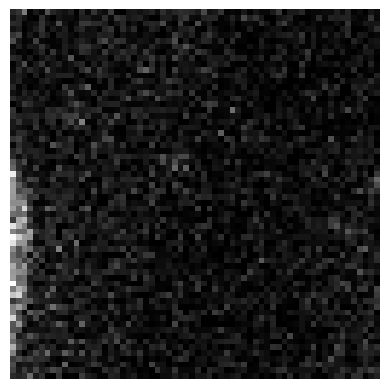

In [ ]:
file_path = './_test2/HV110_P0500510000_random_patches.h5/X/1'

im , _ = hdf5_reader()(file_path)
plot_image(im)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()